# Otimização de Rotas Hospitalares com AG + LLM (Ollama) — Demo no Google Colab

Este notebook roda o projeto completo no Colab:

1. Clona o repositório e instala as dependências;
2. Roda os testes automatizados;
3. Executa o Algoritmo Genético (gera mapa, gráficos e relatórios);
4. Instala e sobe o **Ollama** dentro do próprio Colab (sem depender da sua máquina local);
5. Gera relatórios/instruções com a LLM local e permite fazer perguntas em linguagem natural;
6. Empacota os resultados em `outputs.zip` para download.

> Dica: em *Ambiente de execução > Alterar tipo de ambiente de execução*, uma GPU acelera a LLM, mas **não é obrigatória** — `llama3.2` roda em CPU também.


## 1. Clonar o repositório e instalar dependências

In [1]:
!git clone https://github.com/BrunoAkira/Algoritmo-genetico-llm-hospital.git
%cd Algoritmo-genetico-llm-hospital
!pip install -q -r requirements.txt


Cloning into 'Algoritmo-genetico-llm-hospital'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 95 (delta 36), reused 68 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 53.16 KiB | 812.00 KiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/Algoritmo-genetico-llm-hospital


### 1.1 Aplicar correção de timeout do Ollama (temporário)

O repositório público ainda não tem a correção do timeout/erro da integração com o
Ollama (o commit está pronto localmente, mas o push está bloqueado por permissão).
Esta célula sobrescreve os 3 arquivos afetados com a versão corrigida, para o
notebook já funcionar hoje. Quando o repositório for atualizado, esta célula deixa
de ser necessária e pode ser removida.

In [2]:
from pathlib import Path

Path("src/llm_service.py").write_text(
    'import json\nimport urllib.error\nimport urllib.request\nfrom pathlib import Path\n\nfrom src.prompts import (\n    build_driver_instructions_prompt,\n    build_improvement_prompt,\n    build_operations_report_prompt,\n    build_question_prompt,\n)\n\n\nclass OllamaLLMService:\n    """Integra o projeto com uma LLM local via Ollama, sem API paga e sem chave externa."""\n\n    def __init__(\n        self,\n        model: str = "llama3.2",\n        base_url: str = "http://localhost:11434",\n        timeout: int = 600,\n    ) -> None:\n        """Define o modelo local, o endereço da API REST do Ollama e o timeout de geração."""\n        self.model = model\n        self.base_url = base_url.rstrip("/")\n        self.timeout = timeout\n\n    def generate(self, prompt: str) -> str:\n        """Envia um prompt ao Ollama e retorna o texto gerado pela LLM local."""\n        url = f"{self.base_url}/api/generate"\n        body = {\n            "model": self.model,\n            "prompt": prompt,\n            "stream": False,\n            "options": {\n                # Temperatura baixa reduz respostas criativas demais e deixa o relatório mais consistente.\n                "temperature": 0.2,\n                # Limita o tamanho da resposta para evitar relatórios excessivamente longos.\n                "num_predict": 1200,\n            },\n        }\n        request = urllib.request.Request(\n            url=url,\n            data=json.dumps(body).encode("utf-8"),\n            headers={"Content-Type": "application/json"},\n            method="POST",\n        )\n\n        try:\n            with urllib.request.urlopen(request, timeout=self.timeout) as response:\n                payload = json.loads(response.read().decode("utf-8"))\n        except urllib.error.URLError as exc:\n            raise RuntimeError(\n                "Não foi possível conectar ao Ollama. "\n                "Verifique se o Ollama está instalado e rodando com: ollama serve"\n            ) from exc\n        except TimeoutError as exc:\n            # Em CPU (sem GPU), gerar respostas longas pode ultrapassar o timeout padrão.\n            raise RuntimeError(\n                f"O Ollama não respondeu em {self.timeout}s. Isso é comum ao rodar em CPU "\n                "(por exemplo, no Google Colab sem GPU). Tente usar uma GPU, aumentar o "\n                "timeout (--llm-timeout) ou reduzir num_predict em src/llm_service.py."\n            ) from exc\n\n        return payload.get("response", "").strip()\n\n    def generate_driver_instructions(self, payload: dict) -> str:\n        """Gera instruções detalhadas para motoristas a partir do JSON de rotas."""\n        return self.generate(build_driver_instructions_prompt(payload))\n\n    def generate_operations_report(self, payload: dict) -> str:\n        """Gera relatório operacional com análise de eficiência, riscos e melhorias."""\n        return self.generate(build_operations_report_prompt(payload))\n\n    def suggest_improvements(self, payload: dict) -> str:\n        """Gera sugestões de melhoria logística usando a LLM local."""\n        return self.generate(build_improvement_prompt(payload))\n\n    def answer_question(self, payload: dict, question: str) -> str:\n        """Responde perguntas em linguagem natural sobre as rotas usando a LLM local."""\n        return self.generate(build_question_prompt(payload, question))\n\n\nclass LocalRuleBasedService:\n    """Gera textos por regras locais quando a LLM não está habilitada ou disponível."""\n\n    def generate_driver_instructions_for_route(self, route: dict) -> str:\n        """Cria instruções simples para uma rota específica sem usar LLM."""\n        if not route["stops"]:\n            return f"{route[\'vehicle_name\']}: veículo sem entregas programadas."\n\n        stops = " -> ".join(stop["name"] for stop in route["stops"])\n        critical = [stop["name"] for stop in route["stops"] if stop["priority"] == 3]\n        critical_text = ""\n        if critical:\n            critical_text = " Priorize atenção nas entregas críticas: " + ", ".join(critical) + "."\n\n        return (\n            f"{route[\'vehicle_name\']}: sair da base e seguir a sequência {stops}. "\n            f"Distância estimada: {route[\'distance_km\']} km. "\n            f"Carga estimada: {route[\'load_kg\']} kg."\n            f"{critical_text} Conferir comprovante de entrega em cada parada."\n        )\n\n    def generate_operations_summary(self, payload: dict) -> str:\n        """Cria um resumo operacional simples com métricas calculadas pelo algoritmo."""\n        total_distance = sum(route["distance_km"] for route in payload["routes"])\n        total_late = sum(route["late_deliveries"] for route in payload["routes"])\n        overloaded = [route["vehicle_name"] for route in payload["routes"] if route["capacity_excess_kg"] > 0]\n        autonomy = [route["vehicle_name"] for route in payload["routes"] if route["autonomy_excess_km"] > 0]\n        return (\n            f"Resumo operacional: a malha planejada possui {total_distance:.2f} km de distância estimada. "\n            f"Foram identificadas {total_late} entregas com atraso projetado. "\n            f"Veículos com excesso de capacidade: {\', \'.join(overloaded) if overloaded else \'nenhum\'}. "\n            f"Veículos com excesso de autonomia: {\', \'.join(autonomy) if autonomy else \'nenhum\'}."\n        )\n\n    def suggest_improvements(self, payload: dict) -> list[str]:\n        """Sugere melhorias por regras para manter o projeto útil mesmo sem Ollama."""\n        suggestions = []\n        for route in payload["routes"]:\n            if route["capacity_excess_kg"] > 0:\n                suggestions.append(f"Redistribuir carga do {route[\'vehicle_name\']} para evitar excesso de capacidade.")\n            if route["autonomy_excess_km"] > 0:\n                suggestions.append(f"Reduzir distância do {route[\'vehicle_name\']} ou alocar veículo com maior autonomia.")\n            if route["late_deliveries"] > 0:\n                suggestions.append(f"Revisar a ordem de entregas do {route[\'vehicle_name\']} para reduzir atrasos.")\n        if not suggestions:\n            suggestions.append("Manter o planejamento atual e monitorar tempos reais de entrega para calibrar o modelo.")\n        return suggestions\n\n\ndef save_text(path: str | Path, content: str) -> None:\n    """Salva um texto em arquivo, criando a pasta de destino quando necessário."""\n    Path(path).parent.mkdir(parents=True, exist_ok=True)\n    with open(path, "w", encoding="utf-8") as file:\n        file.write(content)\n\n\ndef generate_rule_based_driver_file(payload: dict, output_path: str | Path) -> None:\n    """Gera o arquivo de instruções por regras locais, sem depender de LLM."""\n    service = LocalRuleBasedService()\n    lines = ["# Instruções para Motoristas", "", "Fonte: regras locais do sistema, sem LLM.", ""]\n    for route in payload["routes"]:\n        lines.append(f"- {service.generate_driver_instructions_for_route(route)}")\n    lines.extend(["", "## Resumo operacional", "", service.generate_operations_summary(payload), "", "## Sugestões de melhoria", ""])\n    for suggestion in service.suggest_improvements(payload):\n        lines.append(f"- {suggestion}")\n    save_text(output_path, "\\n".join(lines))\n\n\ndef generate_ollama_outputs(\n    payload: dict,\n    output_dir: str | Path,\n    model: str = "llama3.2",\n    base_url: str = "http://localhost:11434",\n    timeout: int = 600,\n) -> None:\n    """Gera relatórios com LLM local usando Ollama e salva os arquivos em outputs/."""\n    service = OllamaLLMService(model=model, base_url=base_url, timeout=timeout)\n    output_dir = Path(output_dir)\n\n    # Cada chamada usa um prompt específico para atender os requisitos de instruções, relatórios e melhorias.\n    driver_instructions = service.generate_driver_instructions(payload)\n    operations_report = service.generate_operations_report(payload)\n    improvements = service.suggest_improvements(payload)\n\n    save_text(output_dir / "llm_driver_instructions.md", driver_instructions)\n    save_text(output_dir / "llm_operations_report.md", operations_report)\n    save_text(output_dir / "llm_improvement_suggestions.md", improvements)\n',
    encoding="utf-8",
)

Path("src/qa_service.py").write_text(
    'import json\nfrom pathlib import Path\n\nfrom src.llm_service import OllamaLLMService\n\n\ndef load_payload(path: str | Path) -> dict:\n    """Carrega o resultado das rotas salvo em JSON pelo run.py."""\n    with open(path, "r", encoding="utf-8") as file:\n        return json.load(file)\n\n\ndef answer_question_with_llm(\n    question: str,\n    payload: dict,\n    model: str = "llama3.2",\n    base_url: str = "http://localhost:11434",\n    timeout: int = 600,\n) -> str:\n    """Responde perguntas em linguagem natural usando uma LLM local servida pelo Ollama."""\n    service = OllamaLLMService(model=model, base_url=base_url, timeout=timeout)\n    return service.answer_question(payload, question)\n',
    encoding="utf-8",
)

Path("run.py").write_text(
    'import argparse\nfrom pathlib import Path\n\nfrom src.baseline import generate_performance_comparison\nfrom src.charts import plot_fitness_history, plot_priority_distribution, plot_vehicle_distances\nfrom src.data_loader import load_deliveries, load_vehicles\nfrom src.llm_service import generate_ollama_outputs, generate_rule_based_driver_file\nfrom src.map_visualizer import create_routes_map\nfrom src.qa_service import answer_question_with_llm, load_payload\nfrom src.report_generator import build_routes_payload, generate_markdown_report, save_routes_json\nfrom src.vrp_solver import VRPSolver\n\n\nDEFAULT_OUTPUT_DIR = Path("outputs")\n\n\ndef add_optimization_arguments(parser: argparse.ArgumentParser) -> None:\n    """Adiciona ao parser os parâmetros usados na execução do Algoritmo Genético."""\n    parser.add_argument("--deliveries", default="data/deliveries.csv", help="Caminho do CSV de entregas.")\n    parser.add_argument("--vehicles", default="data/vehicles.csv", help="Caminho do CSV de veículos.")\n    parser.add_argument("--population-size", type=int, default=120, help="Tamanho da população genética.")\n    parser.add_argument("--generations", type=int, default=400, help="Quantidade de gerações do algoritmo.")\n    parser.add_argument("--elite-size", type=int, default=6, help="Quantidade de indivíduos preservados por elitismo.")\n    parser.add_argument("--mutation-rate", type=float, default=0.30, help="Taxa de mutação por indivíduo.")\n    parser.add_argument("--seed", type=int, default=42, help="Semente aleatória para reprodutibilidade.")\n    parser.add_argument("--output-dir", default="outputs", help="Pasta onde os arquivos serão gerados.")\n\n\ndef add_llm_arguments(parser: argparse.ArgumentParser) -> None:\n    """Adiciona parâmetros de configuração da LLM local executada pelo Ollama."""\n    parser.add_argument("--llm", action="store_true", help="Usa LLM local via Ollama quando aplicável.")\n    parser.add_argument("--llm-model", default="llama3.2", help="Modelo local do Ollama, por exemplo llama3.2.")\n    parser.add_argument("--ollama-url", default="http://localhost:11434", help="URL local da API do Ollama.")\n    parser.add_argument(\n        "--llm-timeout",\n        type=int,\n        default=600,\n        help="Tempo máximo em segundos esperando a resposta do Ollama (aumente em CPU sem GPU).",\n    )\n\n\ndef parse_args() -> argparse.Namespace:\n    """Lê os argumentos do terminal e organiza os modos do sistema em um único arquivo run.py."""\n    parser = argparse.ArgumentParser(\n        description="Sistema local de otimização de rotas hospitalares com AG e LLM via Ollama."\n    )\n    subparsers = parser.add_subparsers(dest="command")\n\n    optimize_parser = subparsers.add_parser("optimize", help="Executa o Algoritmo Genético e gera os artefatos.")\n    add_optimization_arguments(optimize_parser)\n    add_llm_arguments(optimize_parser)\n\n    report_parser = subparsers.add_parser("llm-report", help="Gera relatórios com LLM a partir do routes.json.")\n    report_parser.add_argument("--routes", default="outputs/routes.json", help="Arquivo JSON gerado pela otimização.")\n    report_parser.add_argument("--output-dir", default="outputs", help="Pasta onde os relatórios da LLM serão salvos.")\n    add_llm_arguments(report_parser)\n\n    ask_parser = subparsers.add_parser("ask", help="Responde perguntas sobre rotas usando LLM local via Ollama.")\n    ask_parser.add_argument("question", help="Pergunta em linguagem natural sobre as rotas.")\n    ask_parser.add_argument("--routes", default="outputs/routes.json", help="Arquivo JSON gerado pela otimização.")\n    ask_parser.add_argument("--llm-model", default="llama3.2", help="Modelo local do Ollama, por exemplo llama3.2.")\n    ask_parser.add_argument("--ollama-url", default="http://localhost:11434", help="URL local da API do Ollama.")\n    ask_parser.add_argument(\n        "--llm-timeout",\n        type=int,\n        default=600,\n        help="Tempo máximo em segundos esperando a resposta do Ollama (aumente em CPU sem GPU).",\n    )\n\n    menu_parser = subparsers.add_parser("menu", help="Abre um menu interativo para demonstração local.")\n    add_optimization_arguments(menu_parser)\n    add_llm_arguments(menu_parser)\n\n    # Compatibilidade com o modo antigo: `python run.py --generations 10` continua executando a otimização.\n    add_optimization_arguments(parser)\n    add_llm_arguments(parser)\n\n    args = parser.parse_args()\n    if args.command is None:\n        args.command = "optimize"\n    return args\n\n\ndef run_optimization(args: argparse.Namespace) -> dict:\n    """Executa o Algoritmo Genético, salva mapa/gráficos/relatórios e retorna o payload das rotas."""\n    output_dir = Path(args.output_dir)\n    output_dir.mkdir(exist_ok=True)\n\n    # Entrada do problema: entregas e veículos são carregados de CSV para facilitar testes e ajustes.\n    deliveries = load_deliveries(args.deliveries)\n    vehicles = load_vehicles(args.vehicles)\n\n    # VRPSolver encapsula o Algoritmo Genético aplicado ao problema de múltiplos veículos.\n    solver = VRPSolver(\n        deliveries=deliveries,\n        vehicles=vehicles,\n        population_size=args.population_size,\n        generations=args.generations,\n        elite_size=args.elite_size,\n        mutation_rate=args.mutation_rate,\n        seed=args.seed,\n    )\n    best_individual, best_cost, metrics, history = solver.solve()\n\n    # O routes.json é o contrato entre otimização, relatórios, visualizações e LLM.\n    payload = build_routes_payload(best_individual, vehicles, deliveries, metrics, best_cost)\n    save_routes_json(payload, output_dir / "routes.json")\n\n    # Artefatos locais sem LLM: mapa, gráficos e relatórios determinísticos.\n    generate_markdown_report(payload, output_dir / "daily_report.md")\n    create_routes_map(best_individual, vehicles, deliveries, output_dir / "routes_map.html")\n    plot_fitness_history(history, output_dir / "fitness_evolution.png")\n    plot_vehicle_distances(metrics, output_dir / "vehicle_distance.png")\n    plot_priority_distribution(deliveries, output_dir / "priority_distribution.png")\n    generate_rule_based_driver_file(payload, output_dir / "driver_instructions.md")\n\n    # Comparativo obrigatório para demonstrar desempenho contra uma abordagem simples.\n    generate_performance_comparison(\n        ga_individual=best_individual,\n        ga_cost=best_cost,\n        deliveries=deliveries,\n        vehicles=vehicles,\n        output_path=output_dir / "performance_comparison.md",\n    )\n\n    if getattr(args, "llm", False):\n        # Atende à integração com LLM usando Ollama local, sem API paga.\n        generate_llm_reports(output_dir / "routes.json", output_dir, args.llm_model, args.ollama_url, args.llm_timeout)\n\n    print("Otimização concluída.")\n    print(f"Custo total: {best_cost:.2f}")\n    print(f"Arquivos gerados em {output_dir}/.")\n    return payload\n\n\ndef generate_llm_reports(\n    routes_path: str | Path,\n    output_dir: str | Path,\n    model: str,\n    ollama_url: str,\n    timeout: int = 600,\n) -> None:\n    """Lê o routes.json e gera relatórios/instruções/sugestões usando a LLM local via Ollama."""\n    payload = load_payload(routes_path)\n    generate_ollama_outputs(payload=payload, output_dir=Path(output_dir), model=model, base_url=ollama_url, timeout=timeout)\n    print("Relatórios com LLM gerados.")\n\n\ndef ask_about_routes(question: str, routes_path: str | Path, model: str, ollama_url: str, timeout: int = 600) -> str:\n    """Responde uma pergunta sobre as rotas usando exclusivamente a LLM local via Ollama."""\n    payload = load_payload(routes_path)\n    return answer_question_with_llm(question, payload, model=model, base_url=ollama_url, timeout=timeout)\n\n\ndef run_interactive_menu(args: argparse.Namespace) -> None:\n    """Exibe um menu simples no terminal para demonstrar otimização, LLM e perguntas em um único programa."""\n    output_dir = Path(args.output_dir)\n    routes_path = output_dir / "routes.json"\n\n    while True:\n        print("\\n=== Sistema de Otimização de Rotas Hospitalares ===")\n        print("1 - Executar Algoritmo Genético e gerar artefatos")\n        print("2 - Gerar relatórios com LLM local (Ollama)")\n        print("3 - Perguntar sobre as rotas com LLM local (Ollama)")\n        print("4 - Sair")\n        option = input("Escolha uma opção: ").strip()\n\n        if option == "1":\n            run_optimization(args)\n        elif option == "2":\n            generate_llm_reports(routes_path, output_dir, args.llm_model, args.ollama_url, args.llm_timeout)\n        elif option == "3":\n            question = input("Digite sua pergunta: ").strip()\n            if not question:\n                print("Pergunta vazia. Tente novamente.")\n                continue\n            response = ask_about_routes(\n                question=question,\n                routes_path=routes_path,\n                model=args.llm_model,\n                ollama_url=args.ollama_url,\n                timeout=args.llm_timeout,\n            )\n            print("\\nResposta da LLM:")\n            print(response)\n        elif option == "4":\n            print("Encerrando.")\n            break\n        else:\n            print("Opção inválida.")\n\n\ndef main() -> None:\n    """Direciona a execução para otimização, relatórios LLM, perguntas ou menu interativo."""\n    args = parse_args()\n\n    if args.command == "optimize":\n        run_optimization(args)\n    elif args.command == "llm-report":\n        generate_llm_reports(args.routes, args.output_dir, args.llm_model, args.ollama_url, args.llm_timeout)\n    elif args.command == "ask":\n        print(ask_about_routes(args.question, args.routes, args.llm_model, args.ollama_url, args.llm_timeout))\n    elif args.command == "menu":\n        run_interactive_menu(args)\n\n\nif __name__ == "__main__":\n    main()\n',
    encoding="utf-8",
)

print("Arquivos corrigidos aplicados.")


Arquivos corrigidos aplicados.


## 2. Rodar os testes automatizados

Não depende do Ollama: as chamadas à LLM são simuladas (mock) nos testes.

In [3]:
!pytest -q


............                                                             [100%]
12 passed in 4.58s


## 3. Rodar o Algoritmo Genético (sem LLM)

Gera `outputs/routes.json`, mapa, gráficos e relatórios determinísticos.

In [4]:
!python run.py optimize --generations 400 --population-size 120 --mutation-rate 0.30 --seed 42


Otimização concluída.
Custo total: 18671.10
Arquivos gerados em outputs/.


### 3.1 Visualizar o mapa das rotas otimizadas

In [5]:
from IPython.display import HTML

# No Colab, IFrame(src="arquivo_local.html") costuma dar "conexão com localhost recusada",
# porque ele tenta abrir um servidor HTTP na VM remota que o navegador não alcança.
# Embutir o HTML direto no output da célula evita esse problema.
with open("outputs/routes_map.html", encoding="utf-8") as f:
    routes_map_html = f.read()

HTML(routes_map_html)


### 3.2 Visualizar os gráficos gerados

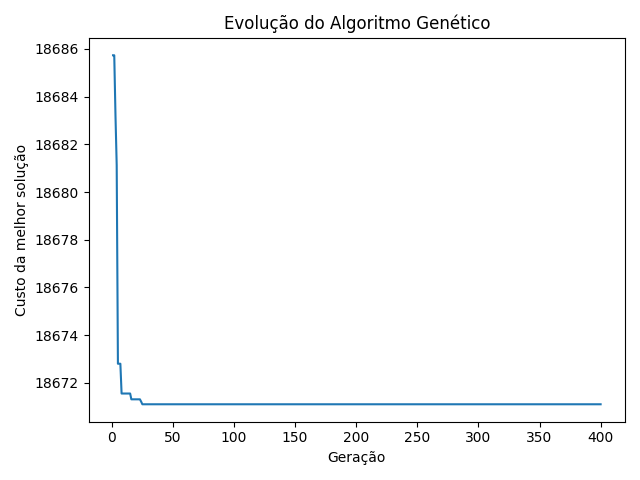

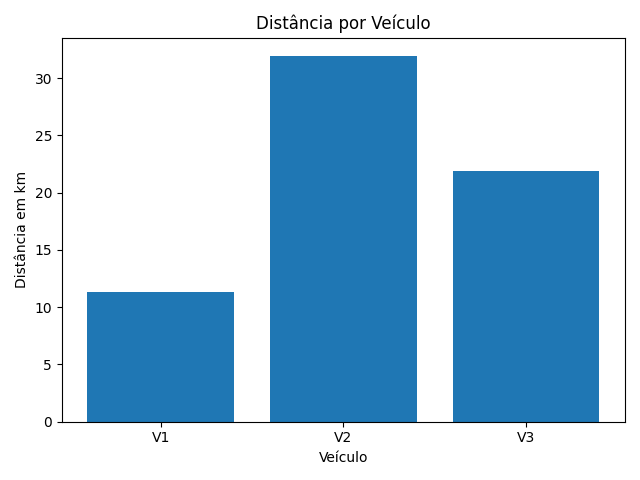

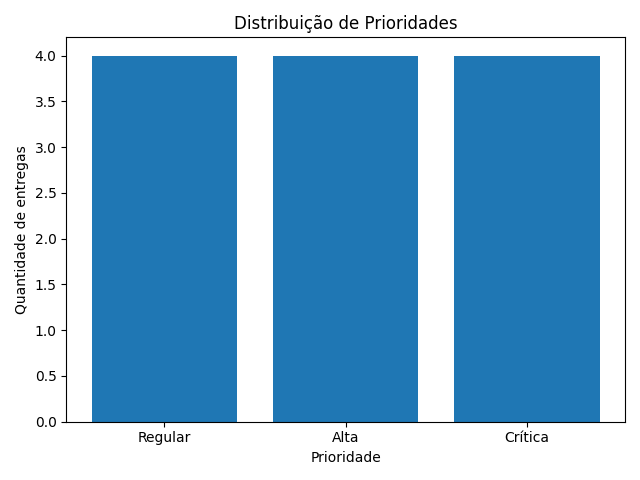

In [6]:
from IPython.display import Image, display

for path in [
    "outputs/fitness_evolution.png",
    "outputs/vehicle_distance.png",
    "outputs/priority_distribution.png",
]:
    display(Image(filename=path))


In [7]:
with open("outputs/performance_comparison.md", encoding="utf-8") as f:
    print(f.read())


# Comparativo de Desempenho

Este comparativo usa uma heurística gulosa de vizinho mais próximo como baseline.
A heurística escolhe sempre a entrega mais próxima disponível, sem evolução genética.

| Abordagem | Custo fitness | Distância total estimada | Observação |
|---|---:|---:|---|
| Algoritmo Genético | 18671.10 | 65.10 km | Solução evoluída com seleção, crossover e mutação |
| Vizinho mais próximo | 20514.67 | 108.67 km | Heurística gulosa usada como referência |

**Melhoria estimada do AG sobre o baseline:** 8.99%

## Interpretação

O Algoritmo Genético tende a encontrar soluções melhores porque avalia diversas combinações de rotas ao longo das gerações.
A heurística gulosa é rápida, mas pode tomar decisões locais ruins, pois escolhe a próxima entrega mais próxima sem considerar o impacto global na frota.

## Observação

Como o AG é heurístico e utiliza aleatoriedade, os resultados podem variar conforme a semente, tamanho da população e número de gerações.


## 4. Instalar e subir o Ollama dentro do Colab

O Colab é uma máquina remota e não enxerga um Ollama rodando no seu computador.
Por isso instalamos e rodamos o Ollama dentro da própria VM do Colab.

In [8]:
# O instalador do Ollama extrai um pacote .zst, mas a imagem do Colab nao vem
# com o zstd por padrao. Instalamos antes para evitar o erro de extracao.
!apt-get -qq update && apt-get -qq install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [9]:
import subprocess
import time

# Sobe o servidor do Ollama em segundo plano (uma célula do Colab não pode
# ficar bloqueada esperando o processo terminar).
ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
time.sleep(5)
print("Ollama server iniciado (PID:", ollama_process.pid, ")")


Ollama server iniciado (PID: 2984 )


In [10]:
# Baixa o modelo local usado pelo projeto (download de alguns GB, pode levar minutos).
!ollama pull llama3.2


## 5. Gerar relatórios com a LLM local

Usa o `outputs/routes.json` já gerado no passo 3 para criar instruções de motoristas,
relatório operacional e sugestões de melhoria.

In [11]:
# Em CPU (sem GPU) a geração pode ser lenta, por isso aumentamos o timeout de espera.
!python run.py llm-report --llm-model llama3.2 --llm-timeout 900


Relatórios com LLM gerados.


In [12]:
for path in [
    "outputs/llm_driver_instructions.md",
    "outputs/llm_operations_report.md",
    "outputs/llm_improvement_suggestions.md",
]:
    print("=" * 80)
    print(path)
    print("=" * 80)
    with open(path, encoding="utf-8") as f:
        print(f.read())
    print()


outputs/llm_driver_instructions.md
**Instruções para Entregas Medicamentosas e de Insumos**

**Sequência Recomendada de Paradas por Veículo:**

*   **Veiculo 1:** 
    *   Hospital Sao Paulo (id 7)
    *   Clinica Vila Mariana (id 9)
    *   Hospital Central (id 1)
*   **Veiculo 2:** 
    *   Hospital Infantil (id 3)
    *   UBS Bela Vista (id 2)
    *   UBS Pinheiros (id 8)
    *   Clinica Butanta (id 12)
    *   Hospital Zona Sul (id 10)
*   **Veiculo 3:** 
    *   UBS Mooca (id 5)
    *   UBS Tatuape (id 11)
    *   Centro de Distribuicao Leste (id 6)
    *   Clinica Zona Norte (id 4)

**Entregas Críticas e Cuidados Especiais:**

*   **Veiculo 1:** 
    *   Hospital Sao Paulo (id 7): Entrega crítica com prazo de entrega de 180 minutos
    *   Clinica Vila Mariana (id 9): Entrega regular
    *   Hospital Central (id 1): Entrega crítica com prazo de entrega de 120 minutos
*   **Veiculo 2:** 
    *   Hospital Infantil (id 3): Entrega crítica com prazo de entrega de 150 minutos
    *   

## 6. Perguntar sobre as rotas em linguagem natural

In [13]:
!python run.py ask "Qual veículo percorreu a maior distância?" --llm-model llama3.2 --llm-timeout 900


Para determinar qual veículo percorreu a maior distância, precisamos analisar as informações disponíveis nos dados.

A partir dos dados fornecidos, podemos observar que o segundo veículo (Veiculo 2) percorreu uma distância de 31.93 km.

No entanto, não há informação sobre a distância total percorrida por cada veículo em todos os casos, apenas para o primeiro veículo (Veiculo 1). Para obter essa informação, precisamos analisar as rotas individuais de cada veículo.

A partir das informações disponíveis, podemos observar que o segundo veículo (Veiculo 2) percorreu uma distância total de 31.93 km, mas não há informação sobre a distância total percorrida pelo primeiro veículo (Veiculo 1).

Portanto, não é possível determinar qual veículo percorreu a maior distância sem mais informações.

Se você tiver mais detalhes sobre as rotas individuais de cada veículo, posso ajudá-lo a determinar qual veículo percorreu a maior distância.


In [14]:
!python run.py ask "Sugira melhorias para reduzir atrasos nas entregas críticas" --llm-model llama3.2 --llm-timeout 900


Com base nos dados fornecidos, não há informações disponíveis sobre atrasos nas entregas críticas ou rotas específicas para reduzir esses atrasos.

No entanto, posso sugerir algumas melhorias gerais para otimizar as entregas medicamentosas e de insumos:

1. **Avaliação da prioridade**: Avalie a prioridade das entregas com base nos critérios de urgência e importância. Isso ajudará a garantir que as entregas críticas sejam priorizadas corretamente.
2. **Otimização da rota**: Use algoritmos genéticos para otimizar as rotas dos veículos, considerando fatores como distância, tempo de entrega e capacidade do veículo.
3. **Alocação eficiente de recursos**: Alocar recursos de forma eficiente pode ajudar a reduzir os atrasos. Por exemplo, se um veículo estiver com mais carga do que sua capacidade máxima, é possível reorganizar a rota para reduzir o tempo de entrega.
4. **Monitoramento e ajustes**: Estabeleça um sistema de monitoramento para acompanhar as entregas em tempo real e fazer ajustes c

## 7. Baixar todos os resultados

Empacota a pasta `outputs/` para download, já que o ambiente do Colab é temporário.

In [15]:
from google.colab import files

!zip -rq outputs.zip outputs
files.download("outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>